# Import Required Libraries

In this section, the necessary Python libraries are imported for dataset handling, preprocessing, and analysis. These libraries support file extraction, data manipulation, and later stages of the NLP pipeline.

In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import zipfile
import pandas as pd

# Mount Google Drive

In [2]:
# Mount Google Drive only when using Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Skipping Drive mount.")

Mounted at /content/drive
Google Drive mounted successfully.


# Extract Dataset and Check the Extracted Dataset

In [3]:
# ============================================================
# EXTRACT DATASET
# ============================================================

zip_path = "/content/drive/MyDrive/ESPORTE/True vs. Fake News Dataset.zip"
extract_path = "/content/fake_news_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
# ============================================================
# CHECK EXTRACTED FILES
# ============================================================

print(os.listdir(extract_path))

['10.True vs. Fake News Dataset']


# Define Dataset Folder

In [5]:
# ============================================================
# DEFINE DATASET FOLDER
# ============================================================

dataset_folder = "/content/fake_news_dataset/10.True vs. Fake News Dataset"

# ============================================================
# CHECK DATASET FILES
# ============================================================

print(os.listdir(dataset_folder))

['truevsfakenews.csv', '10.Description True Vs. Fake News Dataset.txt']


# Load Dataset

In [6]:
df = pd.read_csv(dataset_folder + "/truevsfakenews.csv")

In [7]:
df.head()

,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


In [8]:
print(df.shape)

(20000, 2)


# Check Class Distribution

In [9]:
print(df['label'].value_counts())

label
true    10000
fake    10000
Name: count, dtype: int64


In [10]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20000 non-null  object
 1   label   20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


# Text Preprocessing

In [12]:
# ============================================================
# IMPORT NLP LIBRARIES
# ============================================================

import re
import nltk

In [13]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [14]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text Cleaning Function

In [19]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.6 MB/s eta 0:00:00


In [20]:
import contractions

In [16]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join cleaned words
    text = ' '.join(words)

    return text

In [21]:
df['clean_text'] = df['text'].apply(clean_text)

In [22]:
df[['text', 'clean_text', 'label']].head()

,text,clean_text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake
3,Donald Trump is desperate to stop the investig...,donald trump desperate stop investigation dirt...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",reuters planned parenthood yous medical servic...,true


In [23]:
df['label'] = df['label'].map({
    'fake': 0,
    'true': 1
})

In [24]:
print(df['label'].value_counts())

label
1    10000
0    10000
Name: count, dtype: int64


# Data Visualization

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


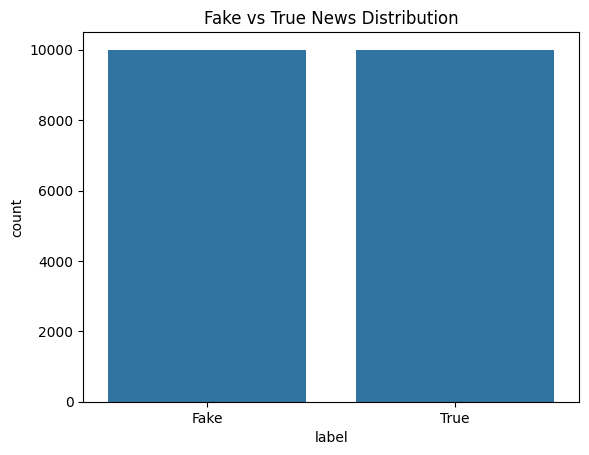

In [26]:
sns.countplot(x='label', data=df)

plt.title("Fake vs True News Distribution")
plt.xticks([0, 1], ['Fake', 'True'])

plt.show()

In [27]:
!pip install wordcloud

In [28]:
from wordcloud import WordCloud

# Word Cloud Visualization

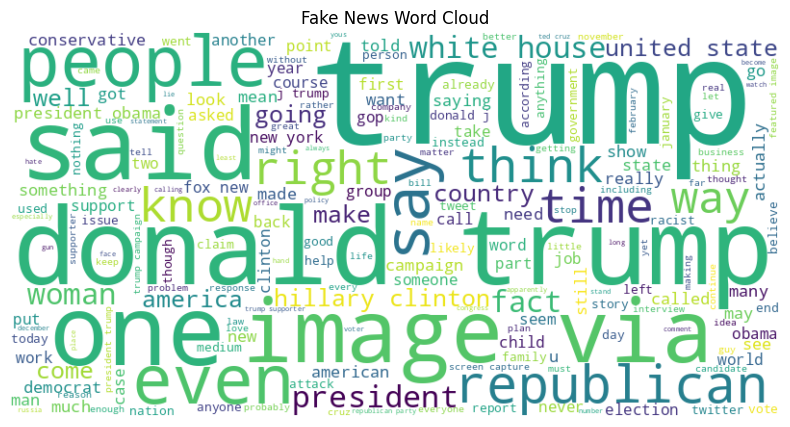

In [29]:
fake_words = ' '.join(
    df[df['label'] == 0]['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_words)

plt.figure(figsize=(10, 5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Fake News Word Cloud")

plt.show()

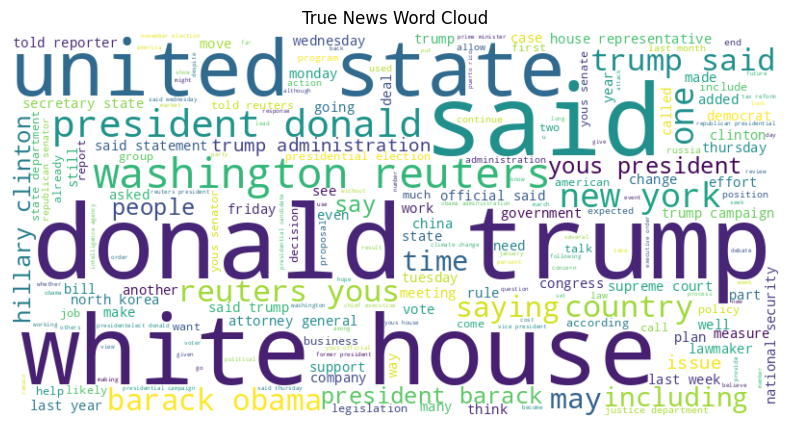

In [30]:
true_words = ' '.join(
    df[df['label'] == 1]['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(true_words)

plt.figure(figsize=(10, 5))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("True News Word Cloud")

plt.show()

# Train-Test Split and Tokenization

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X = df['clean_text']
y = df['label']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [34]:
print("Training Data:", len(X_train))
print("Testing Data :", len(X_test))

Training Data: 16000
Testing Data : 4000


In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [36]:
tokenizer = Tokenizer(num_words=10000)

In [37]:
tokenizer.fit_on_texts(X_train)

In [38]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [39]:
print(X_train.iloc[0])
print(X_train_seq[0])

reuters following people mentioned contender senior role yous presidentelect donald trump assembles administration taking office january according reuters source medium report trump already named number people top job administration sonny perdue former georgia governor elsa murano undersecretary agriculture food safety president george w bush former president texas university chuck conner former acting secretary yous agriculture department current head national council farmer cooperative abel maldonado former lieutenant governor california coowner runway vineyard tim huelskamp republican yous representative kansa sid miller texas agriculture commissioner navy admiral mike rogers director national security agency ronald burgess retired yous army lieutenant general former defense intelligence agency chief robert cardillo director national geospatialintelligence agency pete hoekstra republican former yous representative michigan john allison former chief executive officer regional bank bb

In [40]:
sequence_lengths = [len(seq) for seq in X_train_seq]

print("Maximum Length:", max(sequence_lengths))
print("Average Length:", int(sum(sequence_lengths) / len(sequence_lengths)))

Maximum Length: 3934
Average Length: 222


In [41]:
import numpy as np

max_len = int(np.percentile(sequence_lengths, 95))

print("95th Percentile Length:", max_len)

95th Percentile Length: 468


In [42]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [43]:
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)

X_train_pad shape: (16000, 468)
X_test_pad shape : (4000, 468)


# Model Building and Training

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

In [45]:
vocab_size = 10000
embedding_dim = 128

## Simple RNN Model

In [46]:
model_rnn = Sequential()

model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

model_rnn.add(SimpleRNN(64))

model_rnn.add(Dropout(0.5))

model_rnn.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [47]:
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [48]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Early Stopping Callback

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Train Simple RNN Model

In [50]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 68s 157ms/step - accuracy: 0.5042 - loss: 0.7513 - val_accuracy: 0.6009 - val_loss: 0.6514
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 77s 146ms/step - accuracy: 0.5059 - loss: 0.7532 - val_accuracy: 0.4759 - val_loss: 0.6958
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - accuracy: 0.5017 - loss: 0.7289 - val_accuracy: 0.2609 - val_loss: 0.7400
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - accuracy: 0.5223 - loss: 0.7091 - val_accuracy: 0.5256 - val_loss: 0.6904


In [51]:
rnn_loss, rnn_accuracy = model_rnn.evaluate(X_test_pad, y_test)

print("RNN Test Accuracy:", rnn_accuracy)
print("RNN Test Loss:", rnn_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.6070 - loss: 0.6461
RNN Test Accuracy: 0.6069999933242798
RNN Test Loss: 0.6461332440376282


### RNN Classification Report and Confusion Matrix

In [53]:
from sklearn.metrics import classification_report, confusion_matrix

In [54]:
rnn_pred_prob = model_rnn.predict(X_test_pad)
rnn_pred = (rnn_pred_prob > 0.5).astype("int32")

print("RNN Classification Report:")
print(classification_report(y_test, rnn_pred, target_names=["Fake", "True"]))

125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step
RNN Classification Report:
              precision    recall  f1-score   support

        Fake       0.68      0.44      0.53      2055
        True       0.57      0.78      0.66      1945

    accuracy                           0.61      4000
   macro avg       0.63      0.61      0.60      4000
weighted avg       0.63      0.61      0.60      4000



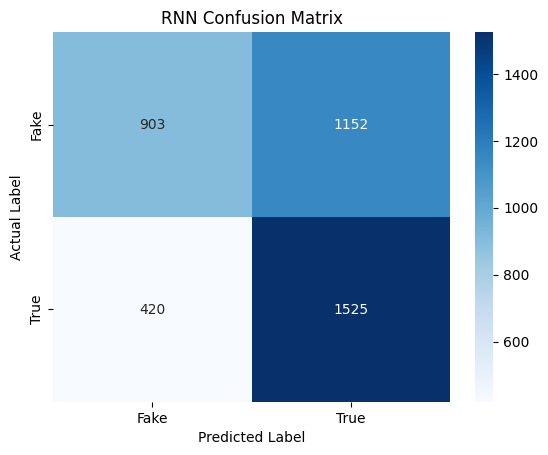

In [55]:
rnn_cm = confusion_matrix(y_test, rnn_pred)

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "True"],
    yticklabels=["Fake", "True"]
)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## LSTM Model

In [52]:
model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

model_lstm.add(LSTM(64))

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(1, activation='sigmoid'))

In [56]:
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

In [58]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [59]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 122s 289ms/step - accuracy: 0.5288 - loss: 0.6888 - val_accuracy: 0.5106 - val_loss: 0.6711
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 114s 285ms/step - accuracy: 0.5291 - loss: 0.6728 - val_accuracy: 0.5266 - val_loss: 0.6737
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 145s 294ms/step - accuracy: 0.5844 - loss: 0.6351 - val_accuracy: 0.9484 - val_loss: 0.2427
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 114s 286ms/step - accuracy: 0.9444 - loss: 0.1944 - val_accuracy: 0.9700 - val_loss: 0.1079
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 148s 302ms/step - accuracy: 0.9621 - loss: 0.1513 - val_accuracy: 0.9438 - val_loss: 0.1880
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 118s 294ms/step - accuracy: 0.9709 - loss: 0.1175 - val_accuracy: 0.9725 - val_loss: 0.0975
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 115s 287ms/step - accuracy: 0.9893 - loss: 0.0563 - val_accuracy: 0.9759 - val_loss: 0.0966
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 115s 287ms/step - accuracy: 0.9939 -

In [60]:
lstm_loss, lstm_accuracy = model_lstm.evaluate(X_test_pad, y_test)

print("LSTM Test Accuracy:", lstm_accuracy)
print("LSTM Test Loss:", lstm_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9793 - loss: 0.0849
LSTM Test Accuracy: 0.9792500138282776
LSTM Test Loss: 0.08486469835042953


## Prepare Sequences for Word2Vec Model

In [61]:
X_train_pad_pre = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='pre',
    truncating='pre'
)

X_test_pad_pre = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='pre',
    truncating='pre'
)

## LSTM with Pretrained Word2Vec Embeddings

In [62]:
model_lstm_pre = Sequential()

model_lstm_pre.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len
    )
)

model_lstm_pre.add(LSTM(64))

model_lstm_pre.add(Dropout(0.5))

model_lstm_pre.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [63]:
model_lstm_pre.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [64]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [65]:
history_lstm_pre = model_lstm_pre.fit(
    X_train_pad_pre,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 123s 300ms/step - accuracy: 0.9721 - loss: 0.1082 - val_accuracy: 0.9750 - val_loss: 0.0709
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 141s 298ms/step - accuracy: 0.9912 - loss: 0.0309 - val_accuracy: 0.9831 - val_loss: 0.0533
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 138s 288ms/step - accuracy: 0.9872 - loss: 0.0350 - val_accuracy: 0.9781 - val_loss: 0.0681
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 115s 288ms/step - accuracy: 0.9979 - loss: 0.0083 - val_accuracy: 0.9806 - val_loss: 0.0524
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 115s 289ms/step - accuracy: 0.9970 - loss: 0.0098 - val_accuracy: 0.9787 - val_loss: 0.0931
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 118s 295ms/step - accuracy: 0.9980 - loss: 0.0075 - val_accuracy: 0.9791 - val_loss: 0.1018
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 118s 295ms/step - accuracy: 0.9988 - loss: 0.0041 - val_accuracy: 0.9794 - val_loss: 0.1025


In [68]:
lstm_pre_loss, lstm_pre_accuracy = model_lstm_pre.evaluate(
    X_test_pad_pre,
    y_test
)

print("Improved LSTM Test Accuracy:", lstm_pre_accuracy)
print("Improved LSTM Test Loss:", lstm_pre_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.9833 - loss: 0.0528
Improved LSTM Test Accuracy: 0.9832500219345093
Improved LSTM Test Loss: 0.05278105288743973


# Model Performance Comparison

In [69]:
results = {
    "Simple RNN": rnn_accuracy,
    "LSTM": lstm_accuracy,
    "Word2Vec LSTM": lstm_pre_accuracy
}

results

{'Simple RNN': 0.6069999933242798,
 'LSTM': 0.9792500138282776,
 'Word2Vec LSTM': 0.9832500219345093}

In [70]:
lstm_pre_pred_prob = model_lstm_pre.predict(X_test_pad_pre)

lstm_pre_pred = (lstm_pre_pred_prob > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step


In [71]:
from sklearn.metrics import confusion_matrix, classification_report

In [72]:
print("Word2Vec LSTM Classification Report:\n")

print(
    classification_report(
        y_test,
        lstm_pre_pred,
        target_names=["Fake", "True"]
    )
)

Word2Vec LSTM Classification Report:

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      2055
        True       0.98      0.99      0.98      1945

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



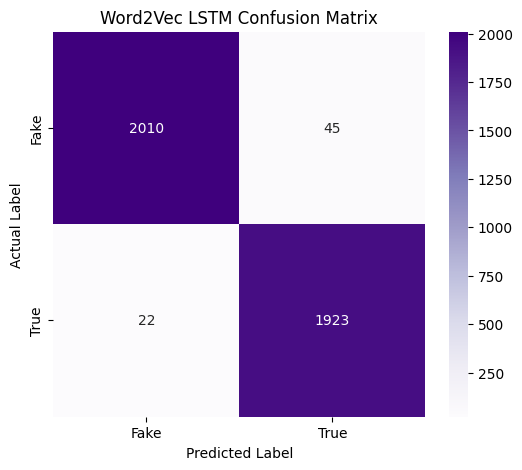

In [73]:
lstm_pre_cm = confusion_matrix(y_test, lstm_pre_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lstm_pre_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Fake', 'True'],
    yticklabels=['Fake', 'True']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Word2Vec LSTM Confusion Matrix")

plt.show()

# Training and Validation Accuracy Comparison

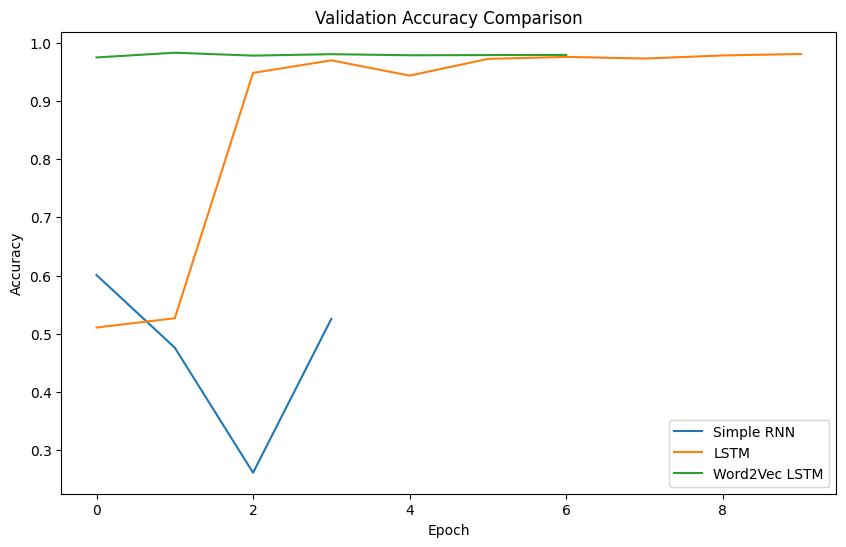

In [74]:
plt.figure(figsize=(10, 6))

# Simple RNN
plt.plot(
    history_rnn.history['val_accuracy'],
    label='Simple RNN'
)

# LSTM
plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM'
)

# Word2Vec LSTM
plt.plot(
    history_lstm_pre.history['val_accuracy'],
    label='Word2Vec LSTM'
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Training and Validation Loss Comparison

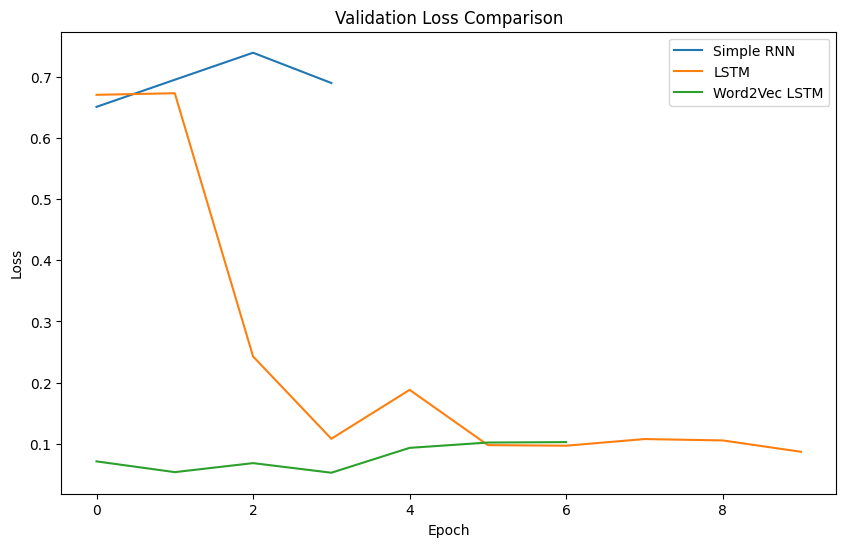

In [75]:
plt.figure(figsize=(10, 6))

# Simple RNN
plt.plot(
    history_rnn.history['val_loss'],
    label='Simple RNN'
)

# LSTM
plt.plot(
    history_lstm.history['val_loss'],
    label='LSTM'
)

# Word2Vec LSTM
plt.plot(
    history_lstm_pre.history['val_loss'],
    label='Word2Vec LSTM'
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [76]:
comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],
    'Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        lstm_pre_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Simple RNN,0.60700
1,LSTM,0.97925
2,Word2Vec LSTM,0.98325


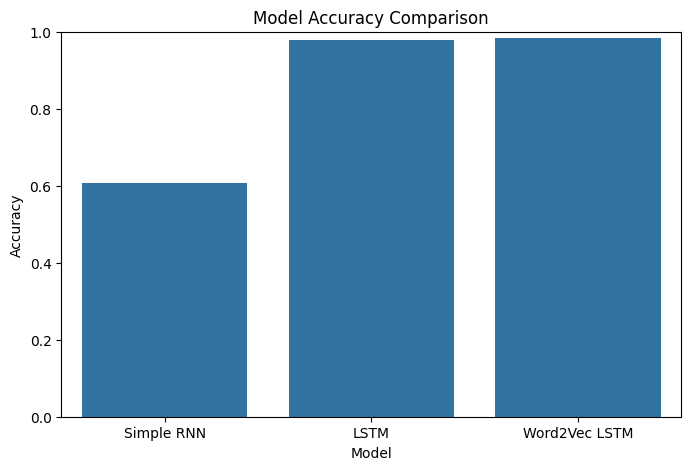

In [77]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [78]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.0 MB/s eta 0:00:00


In [79]:
import gensim.downloader as api

In [80]:
word2vec_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [81]:
print(word2vec_model['news'])

[-0.20825   0.47786   0.52196   1.0587   -0.10045  -1.1269   -1.2581
 -0.11041  -0.074125 -0.77976  -0.37942  -0.2486   -0.39224   0.42972
  0.9806    0.12668  -1.3772   -0.22793  -0.18497   0.41014   0.96781
  0.8916    0.84685   0.57416   0.46455  -1.7287   -0.63918   0.56256
 -0.12651   0.49711   3.3326    0.034399  0.46149  -0.44826  -1.1945
 -0.47593  -0.31927  -0.6442    0.089735  0.073952  0.70755   0.52948
 -0.12034  -0.46779   0.24722   0.28045  -0.62632   1.4458    0.51045
  0.74156 ]


In [82]:
word_index = tokenizer.word_index

embedding_dim = 50

## Create Embedding Matrix

In [84]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():

    if i < vocab_size:

        if word in word2vec_model:
            embedding_matrix[i] = word2vec_model[word]

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (10000, 50)


## Build Word2Vec LSTM Model

In [85]:
model_w2v_lstm = Sequential()

model_w2v_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)

model_w2v_lstm.add(LSTM(64))

model_w2v_lstm.add(Dropout(0.5))

model_w2v_lstm.add(Dense(1, activation='sigmoid'))

In [86]:
model_w2v_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [87]:
history_w2v_lstm = model_w2v_lstm.fit(
    X_train_pad_pre,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 79s 189ms/step - accuracy: 0.9429 - loss: 0.1633 - val_accuracy: 0.9606 - val_loss: 0.1063
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 79s 182ms/step - accuracy: 0.9626 - loss: 0.1114 - val_accuracy: 0.9650 - val_loss: 0.1084
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 83s 186ms/step - accuracy: 0.9688 - loss: 0.0942 - val_accuracy: 0.9722 - val_loss: 0.0734


In [88]:
w2v_lstm_loss, w2v_lstm_accuracy = model_w2v_lstm.evaluate(
    X_test_pad_pre,
    y_test
)

print("Word2Vec + LSTM Test Accuracy:", w2v_lstm_accuracy)
print("Word2Vec + LSTM Test Loss:", w2v_lstm_loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.9670 - loss: 0.0937
Word2Vec + LSTM Test Accuracy: 0.9670000076293945
Word2Vec + LSTM Test Loss: 0.09367026388645172


In [89]:
comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],
    'Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        w2v_lstm_accuracy
    ],
    'Loss': [
        rnn_loss,
        lstm_loss,
        w2v_lstm_loss
    ]
})

comparison_df

,Model,Accuracy,Loss
0,Simple RNN,0.60700,0.646133
1,LSTM,0.97925,0.084865
2,Word2Vec LSTM,0.96700,0.093670


# Real-Time News Prediction Function

In [90]:
def predict_news(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='pre',
        truncating='pre'
    )

    probability = model_w2v_lstm.predict(padded)[0][0]

    if probability >= 0.5:
        prediction = "True News"
    else:
        prediction = "Fake News"

    print("Original Text:", text)
    print("Cleaned Text :", cleaned)
    print("Prediction   :", prediction)
    print("Confidence   :", round(float(probability), 4))

In [91]:
predict_news(
    "NASA confirms new discovery about water on Mars after successful space mission."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Original Text: NASA confirms new discovery about water on Mars after successful space mission.
Cleaned Text : nasa confirms new discovery water mar successful space mission
Prediction   : True News
Confidence   : 0.8097


In [92]:
predict_news(
    "Reuters reports that the government approved a new international climate agreement."
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Original Text: Reuters reports that the government approved a new international climate agreement.
Cleaned Text : reuters report government approved new international climate agreement
Prediction   : True News
Confidence   : 0.9935


# Error Analysis

In [93]:
w2v_pred_prob = model_w2v_lstm.predict(X_test_pad_pre)

w2v_pred_labels = (
    w2v_pred_prob > 0.5
).astype(int).flatten()

error_df = pd.DataFrame({
    'Text': X_test.values,
    'Actual': y_test.values,
    'Predicted': w2v_pred_labels
})

errors = error_df[
    error_df['Actual'] != error_df['Predicted']
]

print("Total Incorrect Predictions:", len(errors))

125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step
Total Incorrect Predictions: 132


In [94]:
errors.head(5)

,Text,Actual,Predicted
29,washington reuters yous senate ethic committee...,1,0
105,nancy pelosi obviously geographically challeng...,0,1
136,washington post reporter took twitter post ima...,0,1
152,isle lewis scotland reuters donald trump playe...,1,0
202,senate minority leader chuck schumer think lik...,0,1


In [95]:
errors['Actual_Label'] = errors['Actual'].map({
    0: 'Fake',
    1: 'True'
})

errors['Predicted_Label'] = errors['Predicted'].map({
    0: 'Fake',
    1: 'True'
})

errors[
    ['Text', 'Actual_Label', 'Predicted_Label']
].head(5)

/tmp/ipykernel_1551/2301676934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Actual_Label'] = errors['Actual'].map({
/tmp/ipykernel_1551/2301676934.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Predicted_Label'] = errors['Predicted'].map({


,Text,Actual_Label,Predicted_Label
29,washington reuters yous senate ethic committee...,True,Fake
105,nancy pelosi obviously geographically challeng...,Fake,True
136,washington post reporter took twitter post ima...,Fake,True
152,isle lewis scotland reuters donald trump playe...,True,Fake
202,senate minority leader chuck schumer think lik...,Fake,True


In [96]:
!pip install gradio

# Gradio Interface for Real-Time Prediction

In [98]:
import gradio as gr

def detect_fake_news(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding='pre',
        truncating='pre'
    )

    probability = model_w2v_lstm.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        prediction = "🟢 TRUE NEWS"
        confidence = probability * 100
    else:
        prediction = "🔴 FAKE NEWS"
        confidence = (1 - probability) * 100

    return f"""
# {prediction}

## Confidence Score: **{confidence:.2f}%**

---

### Cleaned Text
{cleaned}
"""


interface = gr.Interface(
    fn=detect_fake_news,

    inputs=gr.Textbox(
        lines=8,
        placeholder="Enter news article or headline here...",
        label="News Text"
    ),

    outputs=gr.Markdown(
        label="Detection Result"
    ),

    title="📰 Fake News Detection System",

    description="""
This system uses text preprocessing, tokenization, Word2Vec embeddings,
and an LSTM deep learning model to classify news as real or fake.
""",

    theme="soft"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bbe7fa2b14a78ff598.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
